# Tutorial 1: Radio Astronomy Data & Dedispersion Basics

Welcome to the **DMT** (Dispersion Measure Transform) tutorial series.

---

## 1. The Physics of Interstellar Dispersion

Radio signals emitted by astrophysical transients—such as **Pulsars** and **Fast Radio Bursts (FRBs)**—must traverse hundreds, thousands, or billions of light-years of the **Interstellar Medium (ISM)** and **Intergalactic Medium (IGM)** before reaching Earth-based radio telescopes.

The interstellar medium is a tenuous, cold, unmagnetized plasma of free electrons and ions. In such a plasma, electromagnetic waves experience frequency-dependent phase and group velocities governed by the plasma frequency $\nu_p$:

$$\nu_p = \sqrt{\frac{n_e e^2}{\pi m_e}} \approx 8.97 \times 10^{-3} \sqrt{n_e\,[\text{cm}^{-3}]}\;\text{kHz}$$

Because astrophysical observing frequencies $\nu$ (typically $100\,\text{MHz}$ to $8\,\text{GHz}$) greatly exceed $\nu_p$, the index of refraction is:

$$\mu(\nu) = \sqrt{1 - \frac{\nu_p^2}{\nu^2}} \approx 1 - \frac{1}{2} \frac{\nu_p^2}{\nu^2}$$

The wave packets travel at the **group velocity** $v_g = c \,\mu(\nu) < c$. Consequently, lower-frequency components of a broadband pulse are delayed relative to higher frequencies.

The cumulative travel time over distance $L$ is:

$$t(\nu) = \int_0^L \frac{dl}{v_g} \approx \frac{L}{c} + \frac{e^2}{2\pi m_e c} \frac{1}{\nu^2} \int_0^L n_e(l)\,dl$$

We define the **Dispersion Measure (DM)** as the column density of free electrons along the line of sight:

$$\text{DM} \equiv \int_0^L n_e(l)\,dl \quad [\text{pc}\,\text{cm}^{-3}]$$

The differential time delay $\Delta t$ between high frequency $\nu_{\text{high}}$ and low frequency $\nu_{\text{low}}$ is:

$$\Delta t = \mathcal{D} \cdot \text{DM} \left( \nu_{\text{low}}^{-2} - \nu_{\text{high}}^{-2} \right)$$

where $\mathcal{D}$ is the dispersion constant:

$$\mathcal{D} = \frac{e^2}{2\pi m_e c} \approx 4148.808\,\text{MHz}^2\,\text{pc}^{-1}\,\text{cm}^3\,\text{s}$$

*(Note: in radio astronomy, both the Lorimer & Kramer 4148.808 and Manchester & Taylor 4149.377 conventions exist; DMT provides both constants in `dmt.constants`).*


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dispersion constant in MHz^2 pc^-1 cm^3 s
D_CONST = 4148.808

def dispersion_delay(f_mhz, dm):
    """Compute arrival time delay in seconds relative to infinite frequency."""
    return D_CONST * dm * (f_mhz ** -2.0)

# Example: L-band observation (1200 - 1600 MHz) with DM = 100 pc cm^-3
freqs = np.linspace(1200.0, 1600.0, 256)
dm_test = 100.0

delays = dispersion_delay(freqs, dm_test)
total_delay_ms = (delays[0] - delays[-1]) * 1e3

print(f"Total dispersion delay across 1200-1600 MHz band for DM={dm_test} pc cm^-3:")
print(f"  Delta t = {total_delay_ms:.2f} ms")


Total dispersion delay across 1200-1600 MHz band for DM=100.0 pc cm^-3:
  Delta t = 126.05 ms


## 2. The Filterbank / Waterfall Data Format

In modern radio telescope backends, incoming voltage signals from antennas are digitized, channelized using a Polyphase Filterbank (PFB) or FFT, detected as total power (Stokes I), and integrated over time steps $t_{\text{samp}}$ (typically $10\,\mu\text{s}$ to $1\,\text{ms}$).

The resulting dynamic spectrum is represented as a 2D **waterfall matrix**:

$$I[c, s] \quad \text{where } c \in [0, N_{\text{chans}}-1] \text{ (frequency channels)}, \; s \in [0, N_{\text{samps}}-1] \text{ (time samples)}$$

Let's simulate a waterfall containing background radiometer noise and an astrophysical Fast Radio Burst (FRB) pulse.


In [2]:
# Simulation parameters
nchans = 256
f_min = 1200.0   # MHz
f_max = 1600.0   # MHz
tsamp = 1e-3     # 1 millisecond
nsamps = 1024

# Channel frequencies (channel 0 = f_min, channel nchans-1 = f_max)
f_chans = np.linspace(f_min, f_max, nchans, endpoint=False)

# Compute per-channel sample delay for a pulse arriving at time t0
dm_sim = 150.0  # pc cm^-3
t0_samp = 200   # Peak arrives at highest channel at sample 200

delays_sec = dispersion_delay(f_chans, dm_sim) - dispersion_delay(f_max, dm_sim)
delays_samp = np.round(delays_sec / tsamp).astype(int)

# Create simulated waterfall with Gaussian radiometer noise
np.random.seed(42)
waterfall = np.random.normal(loc=0.0, scale=1.0, size=(nchans, nsamps)).astype(np.float32)

# Inject pulse track with amplitude 2.0 per channel
pulse_amp = 2.0
for c in range(nchans):
    arrival_samp = t0_samp + delays_samp[c]
    if 0 <= arrival_samp < nsamps:
        waterfall[c, arrival_samp] += pulse_amp

print(f"Injected pulse with DM = {dm_sim} pc cm^-3 at sample {t0_samp}.")
print(f"Maximum channel delay: {delays_samp[0]} samples ({delays_samp[0] * tsamp * 1e3:.1f} ms)")


Injected pulse with DM = 150.0 pc cm^-3 at sample 200.
Maximum channel delay: 189 samples (189.0 ms)


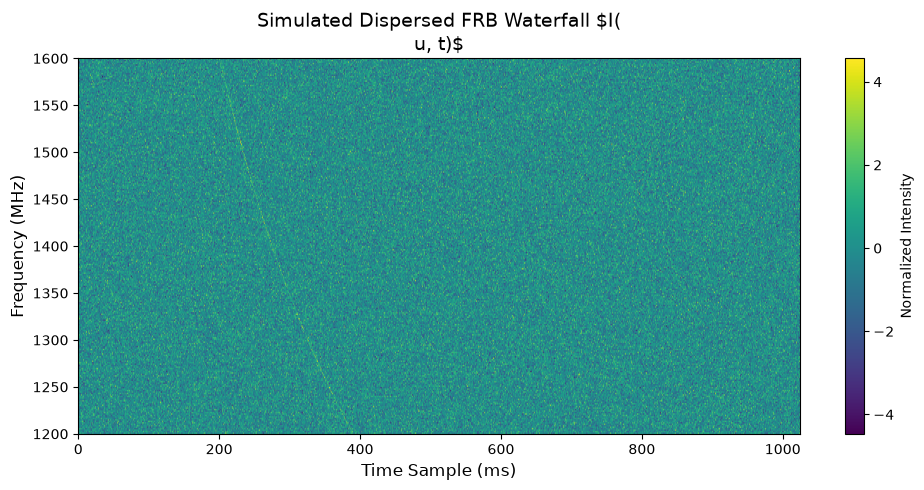

In [3]:
# Visualize the time-frequency waterfall
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(
    waterfall,
    aspect="auto",
    origin="lower",
    extent=[0, nsamps, f_min, f_max],
    cmap="viridis",
)
ax.set_title("Simulated Dispersed FRB Waterfall $I(\nu, t)$", fontsize=14)
ax.set_xlabel("Time Sample (ms)", fontsize=12)
ax.set_ylabel("Frequency (MHz)", fontsize=12)
fig.colorbar(im, ax=ax, label="Normalized Intensity")
plt.tight_layout()
plt.show()


## 3. The Dedispersion Problem: Why Brute-Force Is Slow

Notice how the pulse energy is swept across hundreds of time samples. In any single frequency channel or time bin, the signal-to-noise ratio (SNR) is buried below the noise.

To detect the pulse, we must shift each channel backward in time by its dispersion delay and integrate along the frequency axis:

$$S(t; \text{DM}) = \sum_{c=0}^{N_{\text{chans}}-1} I\left[c, \, t + \Delta s(c, \text{DM})\right]$$

### Computational Complexity
In a blind survey (searching for unknown pulsars or FRBs), we do not know the true DM in advance. We must test a dense grid of $N_{\text{DM}}$ trial values (often $N_{\text{DM}} \sim 1000 - 10{,}000$):
- **Brute-Force Dedispersion:** Requires $N_{\text{DM}} \times N_{\text{chans}} \times N_{\text{samps}}$ operations. For SKA or CHIME scale data ($N_{\text{chans}} = 16{,}384, N_{\text{samps}} = 10^5$), this requires tens of teraflops per second, which easily exhausts real-time compute limits.
- **Fast Dispersion Measure Transform (FDMT):** Uses a recursive, tree-based divide-and-conquer strategy similar to the Fast Fourier Transform (FFT). By iteratively combining pairs of adjacent subbands, FDMT reduces complexity to:

$$\mathcal{O}\left(N_{\text{samps}} \cdot N_{\text{chans}} \cdot \log_2 N_{\text{chans}}\right)$$

This delivers an acceleration factor of $\sim \frac{N_{\text{DM}}}{\log_2 N_{\text{chans}}} \sim 100\times - 1000\times$!

---

## 4. Dedispersion with DMT

Let's run `compute_fdmt` from `dmtlib` on our simulated waterfall to detect the pulse.


In [4]:
from dmtlib import compute_fdmt

# Maximum delay trial to search (in samples)
dt_max = int(delays_samp[0] * 1.5)

# Run the Fast Dispersion Measure Transform
dmt_matrix, plan = compute_fdmt(
    waterfall,
    f_min=f_min,
    f_max=f_max,
    nchans=nchans,
    nsamps=nsamps,
    tsamp=tsamp,
    dt_max=dt_max,
    dt_min=0,
    mode="valid",
)

# Reshape DMT output into (N_dm_trials, N_time_samples)
ndms = plan.dmt_ndms
nsamps_out = plan.dmt_nsamps
dmt_grid = dmt_matrix.reshape(ndms, nsamps_out)

print(f"FDMT Plan summary:")
print(f"  Iterations: {plan.niters}")
print(f"  DM trials:  {ndms}")
print(f"  Output time samples: {nsamps_out}")


FDMT Plan summary:
  Iterations: 8
  DM trials:  284
  Output time samples: 1024


Recovered peak:
  True DM:      150.00 pc cm^-3
  Recovered DM: 150.71 pc cm^-3
  Peak coordinate (DM trial index, time sample): (np.int64(190), np.int64(390))


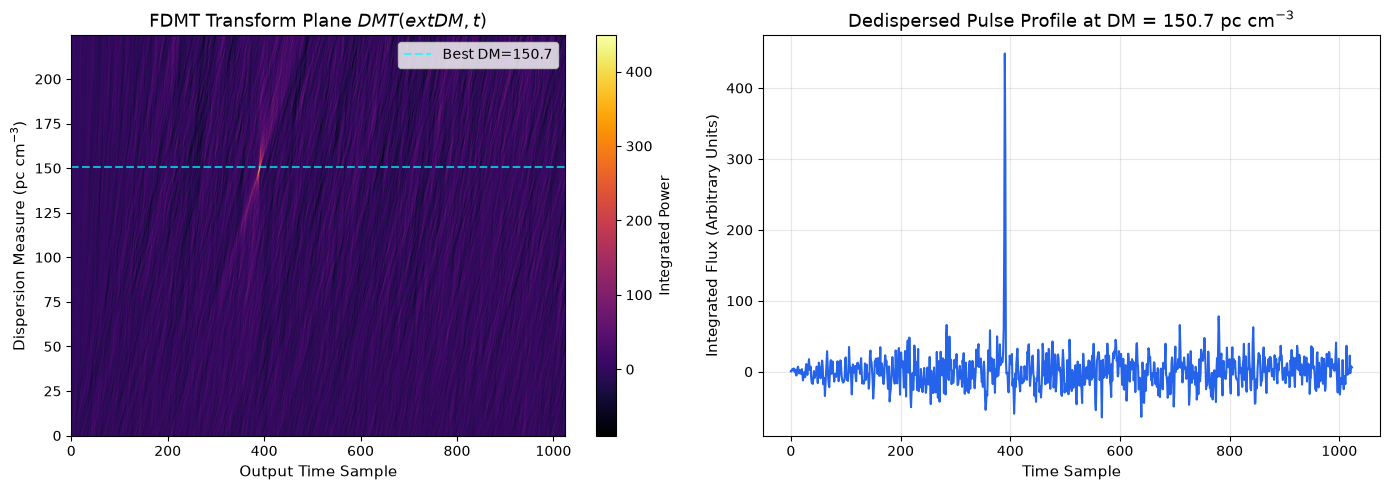

In [5]:
# Map delay trials back to physical DM (pc cm^-3)
dm_trials = plan.dm_grid_final

# Find candidate peak in the DM-time plane
peak_idx = np.unravel_index(np.argmax(dmt_grid), dmt_grid.shape)
best_dm_trial = dm_trials[peak_idx[0]]
best_time_samp = peak_idx[1]

print(f"Recovered peak:")
print(f"  True DM:      {dm_sim:.2f} pc cm^-3")
print(f"  Recovered DM: {best_dm_trial:.2f} pc cm^-3")
print(f"  Peak coordinate (DM trial index, time sample): {peak_idx}")

# Plot the DM-Time plane
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1 = ax1.imshow(
    dmt_grid,
    aspect="auto",
    origin="lower",
    extent=[0, nsamps_out, dm_trials[0], dm_trials[-1]],
    cmap="inferno",
)
ax1.set_title("FDMT Transform Plane $DMT(\text{DM}, t)$", fontsize=13)
ax1.set_xlabel("Output Time Sample", fontsize=11)
ax1.set_ylabel("Dispersion Measure (pc cm$^{-3}$)", fontsize=11)
ax1.axhline(best_dm_trial, color="cyan", linestyle="--", alpha=0.7, label=f"Best DM={best_dm_trial:.1f}")
ax1.legend(loc="upper right")
fig.colorbar(im1, ax=ax1, label="Integrated Power")

# Dedispersed time series profile at best DM
ax2.plot(dmt_grid[peak_idx[0], :], color="#2563eb", lw=1.5)
ax2.set_title(f"Dedispersed Pulse Profile at DM = {best_dm_trial:.1f} pc cm$^{{-3}}$", fontsize=13)
ax2.set_xlabel("Time Sample", fontsize=11)
ax2.set_ylabel("Integrated Flux (Arbitrary Units)", fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary & What's Next

In this tutorial, you learned:
1. The mathematical origin of cold plasma dispersion: $t(\nu) \propto \nu^{-2}$.
2. How radio data is structured into dynamic spectrum waterfalls $I(\nu, t)$.
3. Why brute-force dedispersion is computationally intractable for wide-bandwidth surveys.
4. How `dmtlib.compute_fdmt` concentrates dispersed pulse energy into a sharp peak in the DM-time plane.

In **Tutorial 2: Incoherent FDMT Pipeline & Stepper API**, we dive inside the FDMT algorithm to explore its subband tree recursion, interactive stepping API, and exact noise variance calibration.
